In [71]:
import sys
from pathlib import Path

project_root = Path("..")
sys.path.append(str(project_root))

In [72]:
import pandas as pd
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

from src.utils.ucf101_grouped_classes import ucf101_categories_camelcase
from src.utils.constants import RESULTS_DIR

df = pd.read_csv(RESULTS_DIR / "predictions_prompting_methods.csv")

In [73]:
df.head()

,clip_name,clip_path,label,frame_count,duration_sec,fps,width,height,resolution,UniformSampler64_MeanPooling_TemplatePrompts,UniformSampler64_MeanPooling_MPVRPrompts
0,v_ApplyEyeMakeup_g01_c01,ApplyEyeMakeup\v_ApplyEyeMakeup_g01_c01.avi,ApplyEyeMakeup,164,6.56,25.0,320,240,320x240,ApplyEyeMakeup,ApplyEyeMakeup
1,v_ApplyEyeMakeup_g01_c02,ApplyEyeMakeup\v_ApplyEyeMakeup_g01_c02.avi,ApplyEyeMakeup,123,4.92,25.0,320,240,320x240,ApplyEyeMakeup,ApplyEyeMakeup
2,v_ApplyEyeMakeup_g01_c03,ApplyEyeMakeup\v_ApplyEyeMakeup_g01_c03.avi,ApplyEyeMakeup,259,10.36,25.0,320,240,320x240,ApplyEyeMakeup,ApplyEyeMakeup
3,v_ApplyEyeMakeup_g01_c04,ApplyEyeMakeup\v_ApplyEyeMakeup_g01_c04.avi,ApplyEyeMakeup,235,9.40,25.0,320,240,320x240,ApplyEyeMakeup,ApplyEyeMakeup
4,v_ApplyEyeMakeup_g01_c05,ApplyEyeMakeup\v_ApplyEyeMakeup_g01_c05.avi,ApplyEyeMakeup,296,11.84,25.0,320,240,320x240,ApplyEyeMakeup,ApplyEyeMakeup


In [74]:
pred_templates = "UniformSampler64_MeanPooling_TemplatePrompts"
pred_mpvr = "UniformSampler64_MeanPooling_MPVRPrompts"
label_col = "label"
classes = sorted(df[label_col].unique())


y_true = df[label_col]
y_pred_temp = df[pred_templates]
y_pred_mpvr = df[pred_mpvr]

print("Template accuracy:", accuracy_score(y_true, y_pred_temp))
print("MPVR accuracy:", accuracy_score(y_true, y_pred_mpvr))


Template accuracy: 0.6299233412635474
MPVR accuracy: 0.7311657414750198


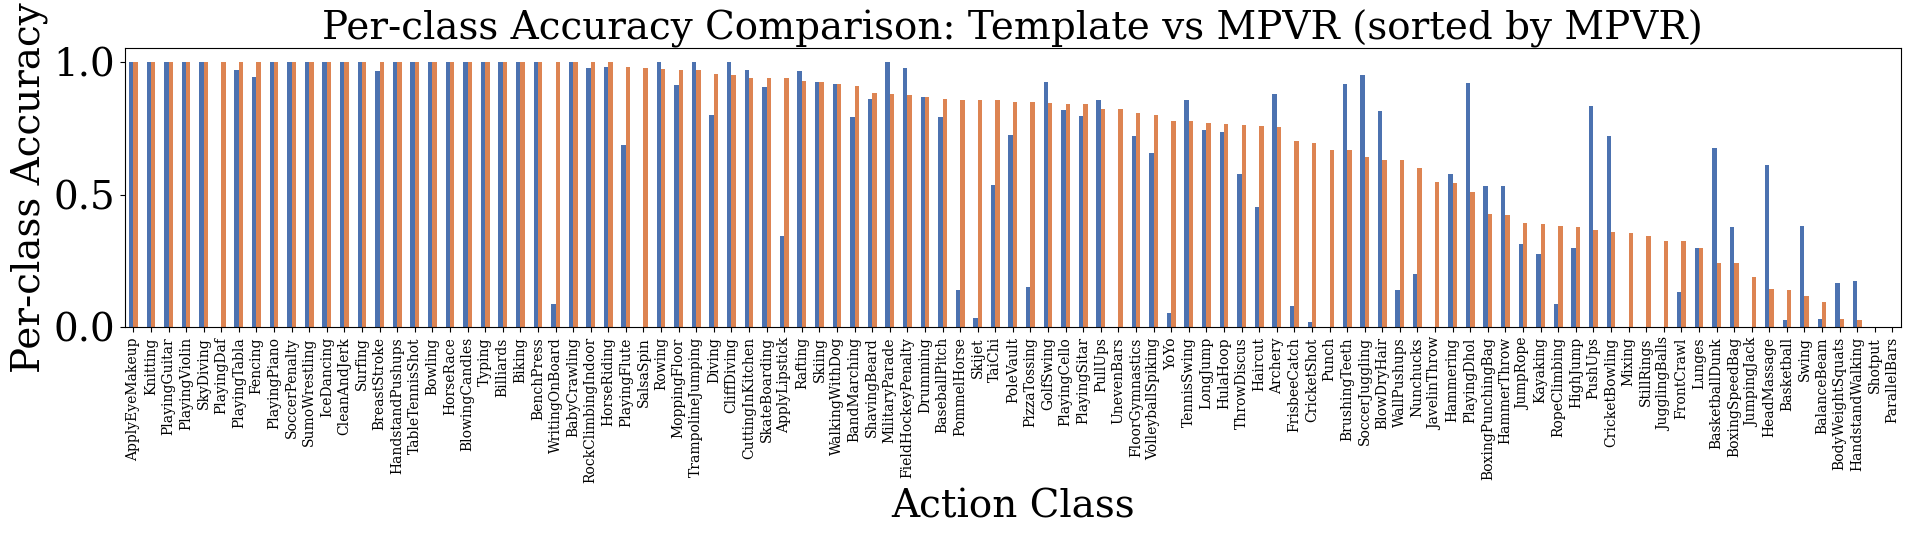

In [75]:
import pandas as pd

class_to_acc_temp = {}
class_to_acc_mpvr = {}

for label, group in df.groupby(label_col):
    true_labels = group[label_col]

    class_to_acc_temp[label] = (group[pred_templates] == true_labels).mean()
    class_to_acc_mpvr[label] = (group[pred_mpvr] == true_labels).mean()

acc_df = pd.DataFrame({"Template": class_to_acc_temp, "MPVR": class_to_acc_mpvr})

acc_df = acc_df.sort_values("MPVR", ascending=False)

template_color = "#4c72b0"
mpvr_color = "#dd8452"

ax = acc_df.plot(
    kind="bar",
    figsize=(20, 6),
    color=[template_color, mpvr_color],
    legend=False,
)
ax.set_ylabel("Per-class Accuracy")
ax.set_xlabel("Action Class")
ax.set_title("Per-class Accuracy Comparison: Template vs MPVR (sorted by MPVR)")

font_size = 28
plt.rcParams.update(
    {
        "font.size": font_size,
        "axes.titlesize": font_size,
        "axes.labelsize": font_size,
        "xtick.labelsize": 10,
        "ytick.labelsize": font_size,
        "legend.fontsize": 22,
        "font.family": "serif",
    }
)

plt.tight_layout()
plt.show()


## Confusion Matrix

The confusion matrix generated by the code below shows the probability that a true label is predicted as another label (based on the column). Row probabilities sum to 100%.


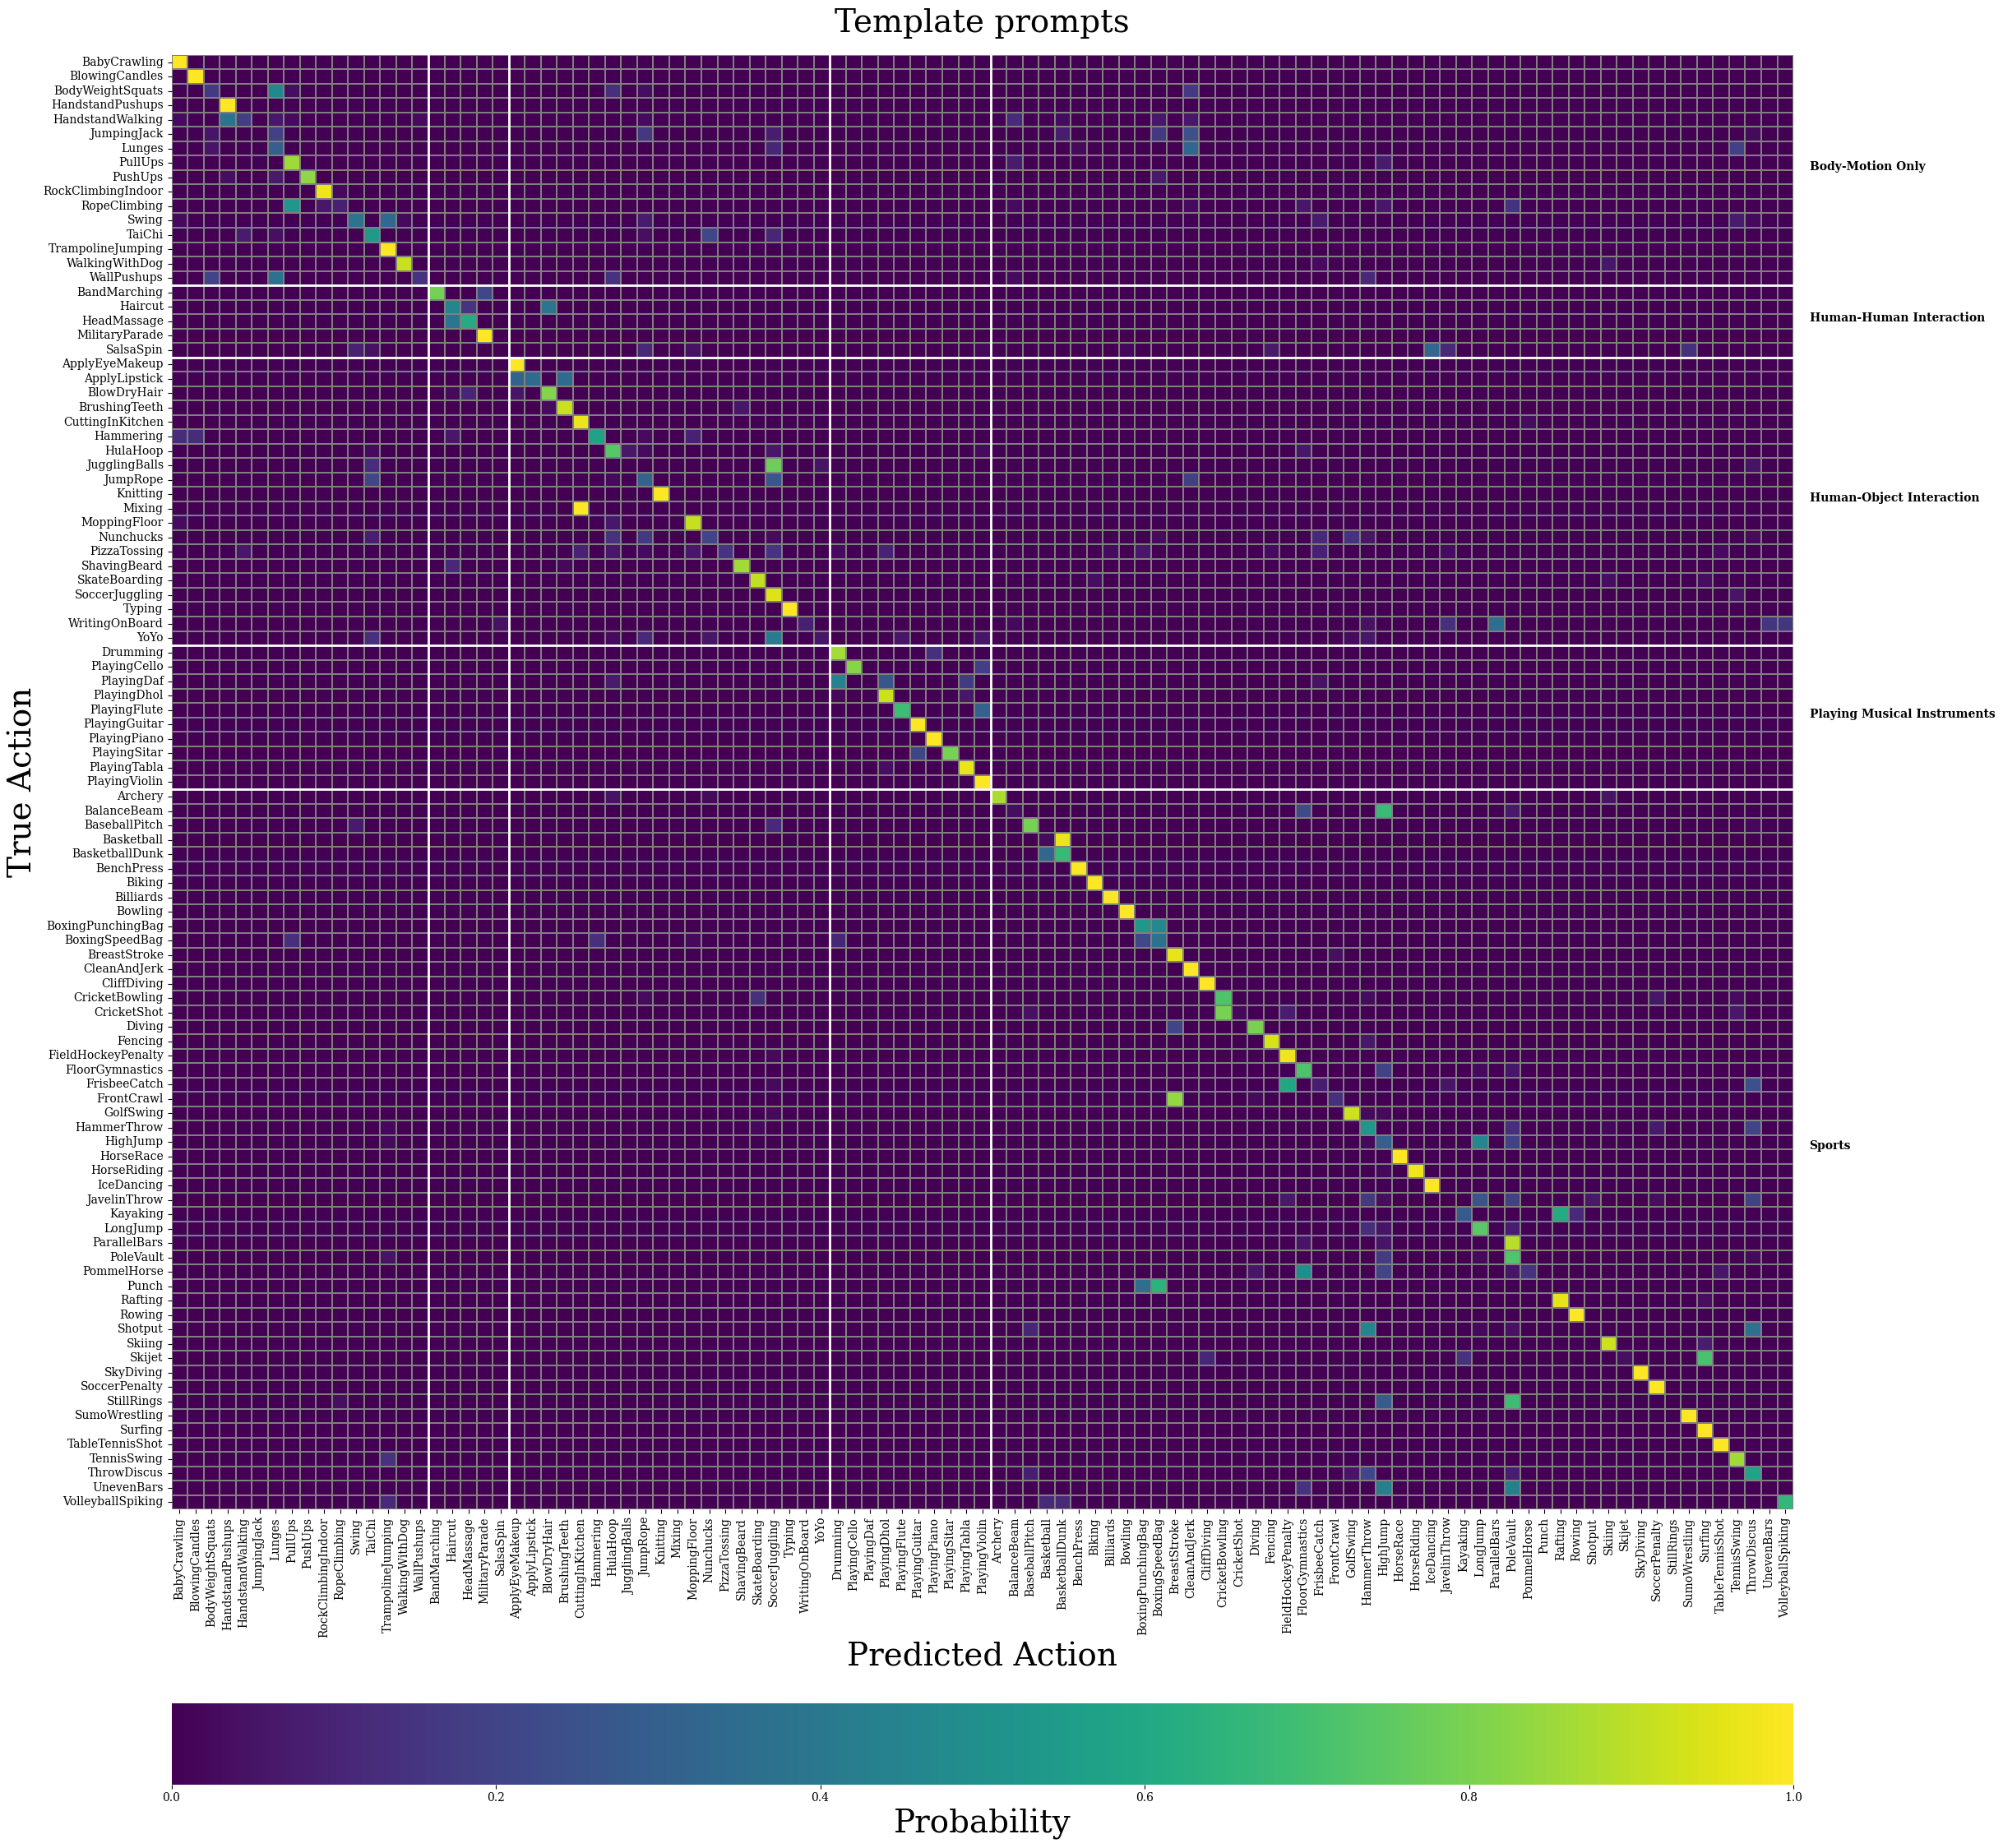

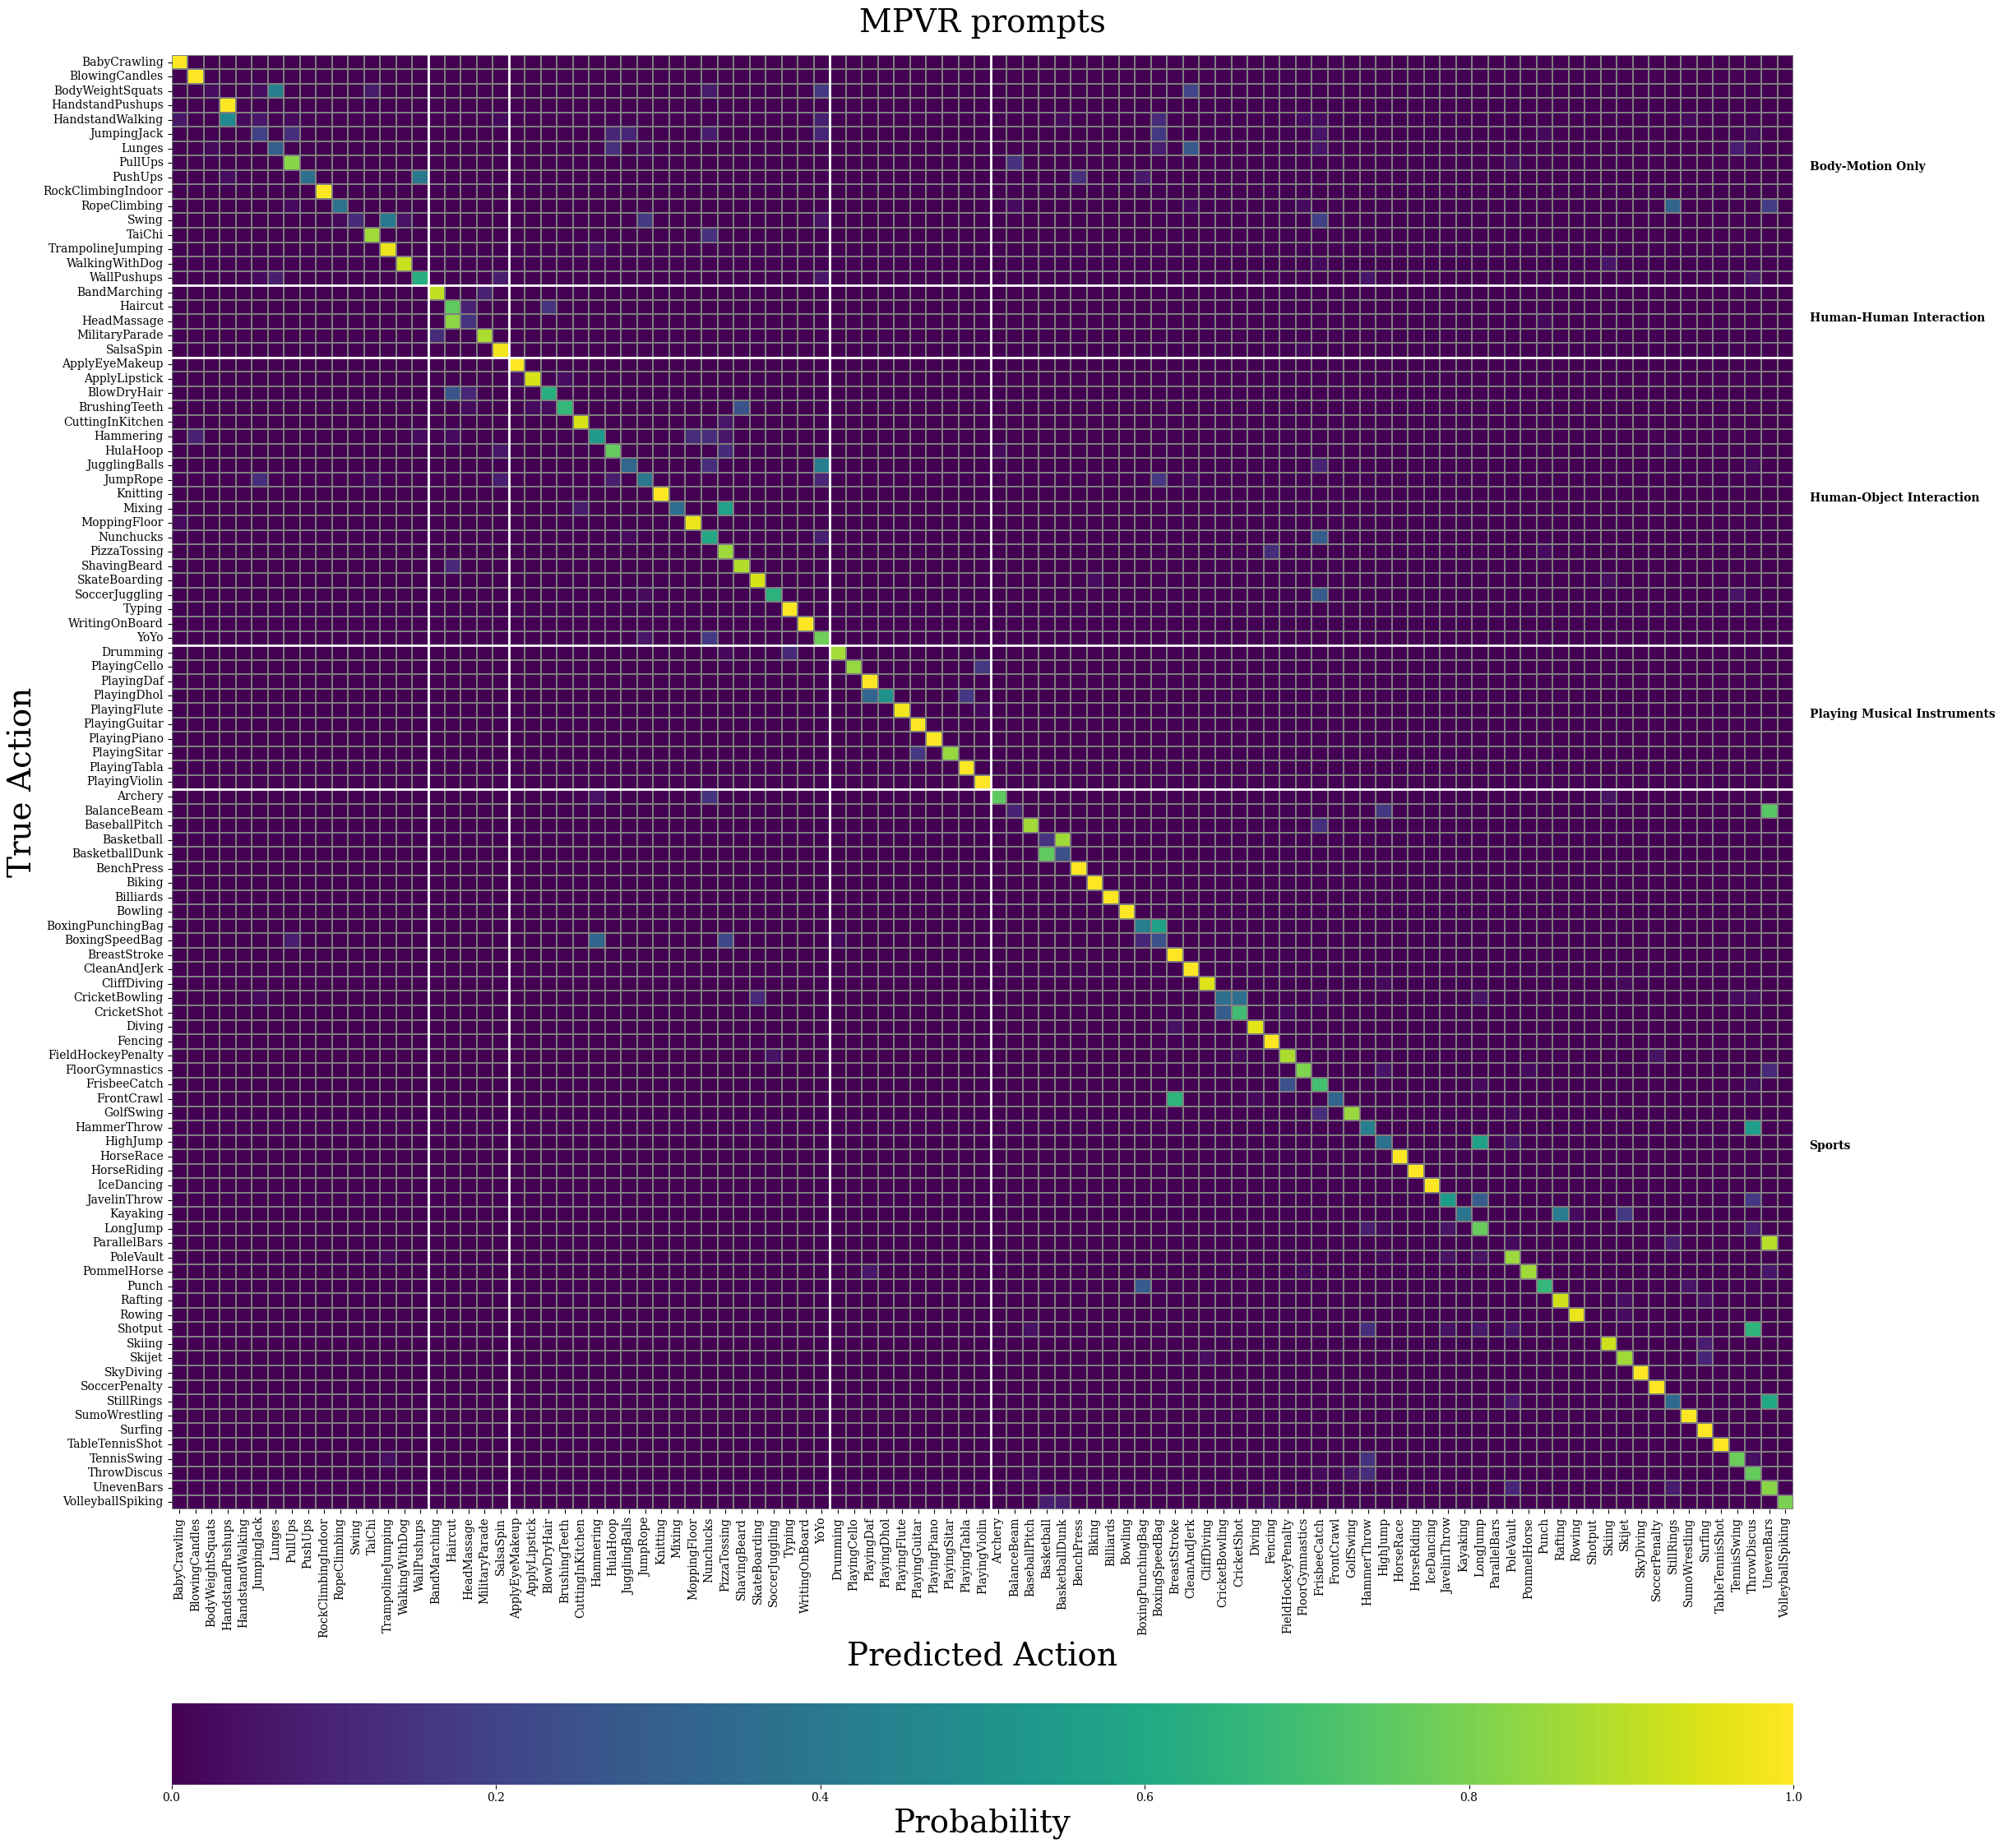

In [76]:
sorted_classes = []
group_boundaries = []
category_ranges = []
current_idx = 0

# collect information about the grouping and indexes of categories so that I can plot the confusion matrix with correctly grouped classes and separation lines.
for category, actions in ucf101_categories_camelcase.items():
    sorted_classes.extend(actions)
    start = current_idx
    current_idx += len(actions)
    end = current_idx

    group_boundaries.append(current_idx)
    category_ranges.append((category, start, end))

# remove the last boundary since that is at the end of the plot
group_boundaries = group_boundaries[:-1]


def plot_confusion(ax: plt.Axes, y_true, y_pred, title: str):
    # using sorted_classes to ensure the matrix follows the group order
    cm = confusion_matrix(y_true, y_pred, labels=sorted_classes, normalize="true")

    # plot the actual confusion matrix with seaborn
    sns.heatmap(
        cm,
        cmap="viridis",
        xticklabels=sorted_classes,
        yticklabels=sorted_classes,
        ax=ax,
        cbar=True,
        cbar_kws={"orientation": "horizontal", "pad": 0.10, "label": "Probability"},
        linewidths=0.01,
        linecolor="gray",
    )
    ax.set_title(title, pad=20)
    ax.set_xlabel("Predicted Action")
    ax.set_ylabel("True Action")

    ax.tick_params(axis="x", rotation=90, labelsize=10)
    ax.tick_params(axis="y", rotation=0, labelsize=10)

    # make lines to seperate actions into categories
    for boundary in group_boundaries:
        ax.axhline(boundary, color="white", linewidth=2)
        ax.axvline(boundary, color="white", linewidth=2)

    # add the action category labels on the chart on the right to label the actions separated by the lines
    for name, start, end in category_ranges:
        category_middle_point = (start + end) / 2

        ax.text(
            x=len(sorted_classes) + 1,
            y=category_middle_point,
            s=name,
            fontsize=10,
            fontweight="bold",
        )


fig, axes = plt.subplots(figsize=(25, 25))
plot_confusion(axes, df[label_col], df[pred_templates], "Template prompts")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(figsize=(25, 25))
plot_confusion(axes, df[label_col], df[pred_mpvr], "MPVR prompts")
plt.tight_layout()
plt.show()